In [247]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import random

from time import time

from scipy.special import comb, loggamma, lambertw
from scipy.stats import multinomial, expon, norm, beta

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test

from silence_tensorflow import silence_tensorflow
silence_tensorflow()
import tensorflow as tf
import tensorflow_probability as tfp
from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

import os, shutil, sys
from pathlib import Path
import json
import subprocess

import thetaflow as thf
# import modelnn2 as thf
print("Thetaflow version: {}".format(thf.__version__))

sys.path.append("../")
# import mpscr_models as mpscr
import mpscr_models_flexible as mpscr
import pwexp_flexible as pwexp
import gndr_utils as utils
import mps

Thetaflow version: 0.0.35


In this notebook, we load all models trained using the OASIS-3 dataset and determine which ones are better fitted.

We will mostly be considering three distinct evaluation metrics, all of which will be applied to the test set:
* The Anderson-Darling test statistic over the randomized normalized quantile residuals of the model;
* The Integrated Censored Weighted Brier Score (IPCW-IBS);
* The Uno's Cumulative Dynamic AUC, also known as Uno's C-Index.

Each metric aims to identify a distinct characteristic of the models. In this specific case, we will not be pondering with great importance the first, Anderson Darling metric, because we have a dataset where most times are censored and there is evidence of a very high proportion of cured patients. There is a clear limitation of the quantile randomized residuals assessment in this case, since, for censored points, we take a random sample from the $U \sim U[ F(y_i), 1 ]$ and transform it using $\Phi^{-1}(U)$ to obtain a proper residual. When the survival function is high, we have a low value for $F(y_i)$ for most data points, leading to the residual being a very close sample from the theoretical standard normal. As we will see, all models present very close AD values for that reason.

The second metric aims at identifying the model's survival curve calibration, in the sense that we measure for each time, a quadratic average between the predicted survival function and the observed survival at that specific time for each strata. Since the IPCW-IBS is an error metric, the lower its value, the best fit.

Finally, the third metric regards to the proportion of failures that is expected by the model at a specific time against the observed proportion of failures at that time. Since this metric essentially mimics an Area-Under-the-Curve (AUC) metric, the higher its value, the best fit.

Applying administrative Type I censorship in 34 patients, of which 2 had observed events.
Train dimension: (552,)
Test dimension: (185,)


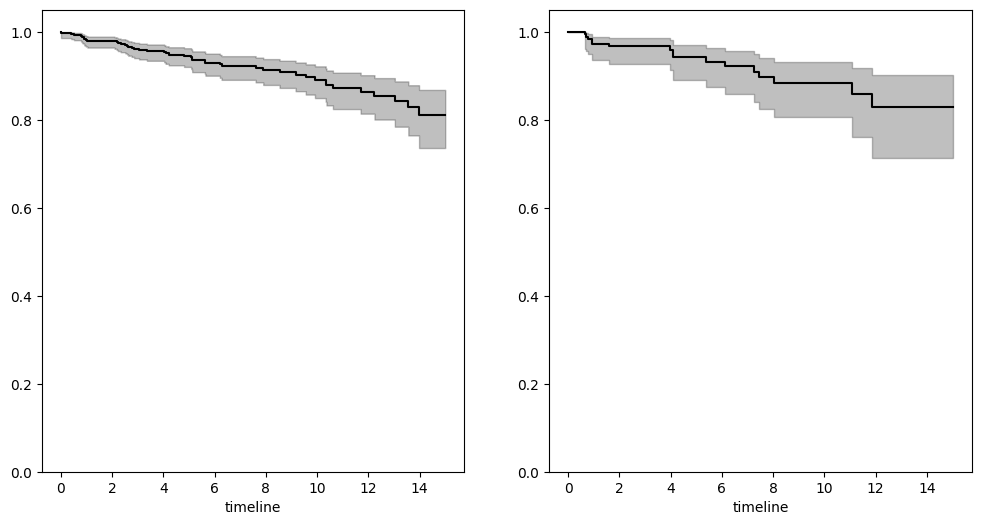

In [2]:
import oasis_utils

# Load exact dataset that was considered in the models applications
# Load OASIS data
# - Split into 75%/25% train/test sets
# - Stratify data according to the number of observed events
df_train, y_train, delta_train, x_train, df_test, y_test, delta_test, x_test =\
oasis_utils.load_oasis_data(long_term_limit = 15, train_size = 0.75, random_state = 20, stratify = True, verbose = True)
# oasis_utils.load_oasis_data(long_term_limit = 15, train_size = 0.75, random_state = 15, stratify = True, verbose = True)


df_train = df_train.iloc[:,1:].reset_index(drop = True)
df_test = df_test.iloc[:,1:].reset_index(drop = True)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))

km = lifelines.KaplanMeierFitter()
km.fit(y_train, delta_train)
km.plot(ax = ax[0], ci_show = True, show_censors = False, label = "Kaplan-Meier", color = "black", legend = False)

km = lifelines.KaplanMeierFitter()
km.fit(y_test, delta_test)
km.plot(ax = ax[1], ci_show = True, show_censors = False, label = "Kaplan-Meier", color = "black", legend = False)

ax[0].set_ylim(0, 1.05)
ax[1].set_ylim(0, 1.05)
plt.show()

In [3]:
def load_model(dist, model_type, base_dist, filename,
               y_train, delta_train, x_train, y_test, delta_test, x_test,
               fixed_q = 0.0, ngrid = 100):
    base_dist = base_dist.lower()
    if(base_dist == "exp" or base_dist == "exponential"):
        filename = "OASIS Results/ExponentialBase/{}".format(filename)
        base_spec = mpscr.BaseExponential()
    elif(base_dist == "weibull"):
        filename = "OASIS Results/WeibullBase/{}".format(filename)
        base_spec = mpscr.BaseWeibull()
    elif(base_dist == "pwexp"):
        filename = "OASIS Results/PwexpBase/{}".format(filename)
        base_spec = mpscr.BasePiecewiseExp(y = y_train, delta = delta_train, n_cuts = 5)
    else:
        raise Exception("Please, provide a valid base distribution.")

    dist = dist.lower()
    if(dist == "poisson"):
        model_spec = mpscr.MPSPoisson()
    elif(dist == "bin" or dist == "binomial"):
        model_spec = mpscr.MPSBinomial(fixed_q)
    elif(dist == "negbin"):
        model_spec = mpscr.MPSNegBinomial()
    elif(dist == "geometric"):
        model_spec = mpscr.MPSNegBinomial(1.0)
    elif(dist == "log" or dist == "logarithmic"):
        model_spec = mpscr.MPSLogarithmic()
    elif(dist == "rgp"):
        model_spec = mpscr.MPSRGP()
    elif(dist == "borel"):
        # The Borel distribution is the Restricted Generalized Poisson with shape parameter q = 1
        model_spec = mpscr.MPSRGP(1.0)
    elif(dist == "geeta"):
        model_spec = mpscr.MPSGeeta()
    elif(dist == "haight" or dist == "catalan"):
        # The Haight distribution is the Geeta with shape parameter q = 2
        model_spec = mpscr.MPSGeeta(2.0)
    else:
        raise Exception("Please, provide a valid subfamily name.")

    if(model_type == "simple"):
        with tf.device("/CPU:0"):
            model = mpscr.build_simple_mpscr_model(y_train, delta_train, model_spec, base_spec, seed = 10 )
            model.load_model(filename)
            model_results = model.get_survival_cure(y_train, delta_train, y_test, delta_test, ngrid = ngrid)
    elif(model_type == "medium"):
        with tf.device("/GPU:0"):
            medium_neural_network, medium_neural_network_call, medium_neural_network_call_nolast = oasis_utils.build_neural_network_structure(1)
            model = mpscr.build_medium_mpscr_model(y_train, delta_train, x_train.shape[1:], model_spec, base_spec,
                                                   neural_network = medium_neural_network, neural_network_call = medium_neural_network_call,
                                                   neural_network_call_nolast = medium_neural_network_call_nolast,
                                                   seed = 10)
            model.load_model(filename)
            model_results = model.get_survival_cure(y_train, delta_train, x_train, y_test, delta_test, x_test, ngrid = ngrid)
    
    
    return model, model_results

### Exponential models

In [4]:
exp_spec = mpscr.BaseExponential()

# Simple models
poisson_simple_model_exp, poisson_simple_results_exp = load_model("poisson", "simple", "exp", "poisson_simple",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
bin5_simple_model_exp, bin5_simple_results_exp = load_model("bin", "simple", "exp", "bin5_simple",
                                                            y_train, delta_train, x_train, y_test, delta_test, x_test,
                                                            fixed_q = 5)
negbin_simple_model_exp, negbin_simple_results_exp = load_model("negbin", "simple", "exp", "negbin_simple",
                                                                y_train, delta_train, x_train, y_test, delta_test, x_test)
log_simple_model_exp, log_simple_results_exp = load_model("log", "simple", "exp", "log_simple",
                                                          y_train, delta_train, x_train, y_test, delta_test, x_test)
rgp_simple_model_exp, rgp_simple_results_exp = load_model("rgp", "simple", "exp", "rgp_simple",
                                                          y_train, delta_train, x_train, y_test, delta_test, x_test)
borel_simple_model_exp, borel_simple_results_exp = load_model("borel", "simple", "exp", "borel_simple",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
geeta_simple_model_exp, geeta_simple_results_exp = load_model("geeta", "simple", "exp", "geeta_simple",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
haight_simple_model_exp, haight_simple_results_exp = load_model("haight", "simple", "exp", "haight_simple",
                                                                y_train, delta_train, x_train, y_test, delta_test, x_test)


# CNN medium models
poisson_medium_model_exp, poisson_medium_results_exp = load_model("poisson", "medium", "exp", "poisson_medium",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
bin5_medium_model_exp, bin5_medium_results_exp = load_model("bin", "medium", "exp", "bin5_medium",
                                                            y_train, delta_train, x_train, y_test, delta_test, x_test,
                                                            fixed_q = 5)
negbin_medium_model_exp, negbin_medium_results_exp = load_model("negbin", "medium", "exp", "negbin_medium",
                                                                y_train, delta_train, x_train, y_test, delta_test, x_test)
log_medium_model_exp, log_medium_results_exp = load_model("log", "medium", "exp", "log_medium",
                                                          y_train, delta_train, x_train, y_test, delta_test, x_test)
rgp_medium_model_exp, rgp_medium_results_exp = load_model("rgp", "medium", "exp", "rgp_medium",
                                                          y_train, delta_train, x_train, y_test, delta_test, x_test)
borel_medium_model_exp, borel_medium_results_exp = load_model("borel", "medium", "exp", "borel_medium",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
geeta_medium_model_exp, geeta_medium_results_exp = load_model("geeta", "medium", "exp", "geeta_medium",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
haight_medium_model_exp, haight_medium_results_exp = load_model("haight", "medium", "exp", "haight_medium",
                                                                y_train, delta_train, x_train, y_test, delta_test, x_test)

Model successfully loaded from OASIS Results/ExponentialBase/poisson_simple.
Model successfully loaded from OASIS Results/ExponentialBase/bin5_simple.
Model successfully loaded from OASIS Results/ExponentialBase/negbin_simple.
Model successfully loaded from OASIS Results/ExponentialBase/log_simple.
Model successfully loaded from OASIS Results/ExponentialBase/rgp_simple.
Model successfully loaded from OASIS Results/ExponentialBase/borel_simple.
Model successfully loaded from OASIS Results/ExponentialBase/geeta_simple.
Model successfully loaded from OASIS Results/ExponentialBase/haight_simple.
Model successfully loaded from OASIS Results/ExponentialBase/poisson_medium.
Model successfully loaded from OASIS Results/ExponentialBase/bin5_medium.
Model successfully loaded from OASIS Results/ExponentialBase/negbin_medium.
Model successfully loaded from OASIS Results/ExponentialBase/log_medium.
Model successfully loaded from OASIS Results/ExponentialBase/rgp_medium.
Model successfully loaded fr

In [5]:
exp_results = [poisson_simple_results_exp, bin5_simple_results_exp, negbin_simple_results_exp, log_simple_results_exp,
               rgp_simple_results_exp, borel_simple_results_exp, geeta_simple_results_exp, haight_simple_results_exp,
               poisson_medium_results_exp, bin5_medium_results_exp, negbin_medium_results_exp, log_medium_results_exp,
               rgp_medium_results_exp, borel_medium_results_exp, geeta_medium_results_exp, haight_medium_results_exp]

### Weibull models

In [6]:
weibull_spec = mpscr.BaseWeibull()

# Simple models
poisson_simple_model_weibull, poisson_simple_results_weibull = load_model("poisson", "simple", "weibull", "poisson_simple",
                                                                          y_train, delta_train, x_train, y_test, delta_test, x_test)
bin5_simple_model_weibull, bin5_simple_results_weibull = load_model("bin", "simple", "weibull", "bin5_simple",
                                                                    y_train, delta_train, x_train, y_test, delta_test, x_test,
                                                                    fixed_q = 5)
negbin_simple_model_weibull, negbin_simple_results_weibull = load_model("negbin", "simple", "weibull", "negbin_simple",
                                                                        y_train, delta_train, x_train, y_test, delta_test, x_test)
log_simple_model_weibull, log_simple_results_weibull = load_model("log", "simple", "weibull", "log_simple",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
rgp_simple_model_weibull, rgp_simple_results_weibull = load_model("rgp", "simple", "weibull", "rgp_simple",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
borel_simple_model_weibull, borel_simple_results_weibull = load_model("borel", "simple", "weibull", "borel_simple",
                                                                      y_train, delta_train, x_train, y_test, delta_test, x_test)
geeta_simple_model_weibull, geeta_simple_results_weibull = load_model("geeta", "simple", "weibull", "geeta_simple",
                                                                      y_train, delta_train, x_train, y_test, delta_test, x_test)
haight_simple_model_weibull, haight_simple_results_weibull = load_model("haight", "simple", "weibull", "haight_simple",
                                                                        y_train, delta_train, x_train, y_test, delta_test, x_test)

# CNN medium models
poisson_medium_model_weibull, poisson_medium_results_weibull = load_model("poisson", "medium", "weibull", "poisson_medium",
                                                                          y_train, delta_train, x_train, y_test, delta_test, x_test)
bin5_medium_model_weibull, bin5_medium_results_weibull = load_model("bin", "medium", "weibull", "bin5_medium",
                                                                    y_train, delta_train, x_train, y_test, delta_test, x_test,
                                                                    fixed_q = 5)
negbin_medium_model_weibull, negbin_medium_results_weibull = load_model("negbin", "medium", "weibull", "negbin_medium",
                                                                        y_train, delta_train, x_train, y_test, delta_test, x_test)
log_medium_model_weibull, log_medium_results_weibull = load_model("log", "medium", "weibull", "log_medium",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
rgp_medium_model_weibull, rgp_medium_results_weibull = load_model("rgp", "medium", "weibull", "rgp_medium",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
borel_medium_model_weibull, borel_medium_results_weibull = load_model("borel", "medium", "weibull", "borel_medium",
                                                                      y_train, delta_train, x_train, y_test, delta_test, x_test)
geeta_medium_model_weibull, geeta_medium_results_weibull = load_model("geeta", "medium", "weibull", "geeta_medium",
                                                                      y_train, delta_train, x_train, y_test, delta_test, x_test)
haight_medium_model_weibull, haight_medium_results_weibull = load_model("haight", "medium", "weibull", "haight_medium",
                                                                        y_train, delta_train, x_train, y_test, delta_test, x_test)

Model successfully loaded from OASIS Results/WeibullBase/poisson_simple.
Model successfully loaded from OASIS Results/WeibullBase/bin5_simple.
Model successfully loaded from OASIS Results/WeibullBase/negbin_simple.
Model successfully loaded from OASIS Results/WeibullBase/log_simple.
Model successfully loaded from OASIS Results/WeibullBase/rgp_simple.
Model successfully loaded from OASIS Results/WeibullBase/borel_simple.
Model successfully loaded from OASIS Results/WeibullBase/geeta_simple.
Model successfully loaded from OASIS Results/WeibullBase/haight_simple.
Model successfully loaded from OASIS Results/WeibullBase/poisson_medium.
Model successfully loaded from OASIS Results/WeibullBase/bin5_medium.
Model successfully loaded from OASIS Results/WeibullBase/negbin_medium.
Model successfully loaded from OASIS Results/WeibullBase/log_medium.
Model successfully loaded from OASIS Results/WeibullBase/rgp_medium.
Model successfully loaded from OASIS Results/WeibullBase/borel_medium.
Model suc

In [7]:
weibull_results = [poisson_simple_results_weibull, bin5_simple_results_weibull, negbin_simple_results_weibull, log_simple_results_weibull,
                   rgp_simple_results_weibull, borel_simple_results_weibull, geeta_simple_results_weibull, haight_simple_results_weibull,
                   poisson_medium_results_weibull, bin5_medium_results_weibull, negbin_medium_results_weibull, log_medium_results_weibull,
                   rgp_medium_results_weibull, borel_medium_results_weibull, geeta_medium_results_weibull, haight_medium_results_weibull]

### PiecewiseExp models

In [8]:
n_cuts = 5
pwexp_spec = mpscr.BasePiecewiseExp(y = y_train, delta = delta_train, n_cuts = n_cuts)

# Simple models
poisson_simple_model_pwexp, poisson_simple_results_pwexp = load_model("poisson", "simple", "pwexp", "poisson_simple",
                                                                      y_train, delta_train, x_train, y_test, delta_test, x_test)
bin5_simple_model_pwexp, bin5_simple_results_pwexp = load_model("bin", "simple", "pwexp", "bin5_simple",
                                                                y_train, delta_train, x_train, y_test, delta_test, x_test,
                                                                fixed_q = 5)
negbin_simple_model_pwexp, negbin_simple_results_pwexp = load_model("negbin", "simple", "pwexp", "negbin_simple",
                                                                    y_train, delta_train, x_train, y_test, delta_test, x_test)
log_simple_model_pwexp, log_simple_results_pwexp = load_model("log", "simple", "pwexp", "log_simple",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
rgp_simple_model_pwexp, rgp_simple_results_pwexp = load_model("rgp", "simple", "pwexp", "rgp_simple",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
borel_simple_model_pwexp, borel_simple_results_pwexp = load_model("borel", "simple", "pwexp", "borel_simple",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
geeta_simple_model_pwexp, geeta_simple_results_pwexp = load_model("geeta", "simple", "pwexp", "geeta_simple",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
haight_simple_model_pwexp, haight_simple_results_pwexp = load_model("haight", "simple", "pwexp", "haight_simple",
                                                                    y_train, delta_train, x_train, y_test, delta_test, x_test)

# CNN medium models
poisson_medium_model_pwexp, poisson_medium_results_pwexp = load_model("poisson", "medium", "pwexp", "poisson_medium",
                                                                      y_train, delta_train, x_train, y_test, delta_test, x_test)
bin5_medium_model_pwexp, bin5_medium_results_pwexp = load_model("bin", "medium", "pwexp", "bin5_medium",
                                                                y_train, delta_train, x_train, y_test, delta_test, x_test,
                                                                fixed_q = 5)
negbin_medium_model_pwexp, negbin_medium_results_pwexp = load_model("negbin", "medium", "pwexp", "negbin_medium",
                                                                    y_train, delta_train, x_train, y_test, delta_test, x_test)
log_medium_model_pwexp, log_medium_results_pwexp = load_model("log", "medium", "pwexp", "log_medium",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
rgp_medium_model_pwexp, rgp_medium_results_pwexp = load_model("rgp", "medium", "pwexp", "rgp_medium",
                                                              y_train, delta_train, x_train, y_test, delta_test, x_test)
borel_medium_model_pwexp, borel_medium_results_pwexp = load_model("borel", "medium", "pwexp", "borel_medium",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
geeta_medium_model_pwexp, geeta_medium_results_pwexp = load_model("geeta", "medium", "pwexp", "geeta_medium",
                                                                  y_train, delta_train, x_train, y_test, delta_test, x_test)
haight_medium_model_pwexp, haight_medium_results_pwexp = load_model("haight", "medium", "pwexp", "haight_medium",
                                                                    y_train, delta_train, x_train, y_test, delta_test, x_test)

Model successfully loaded from OASIS Results/PwexpBase/poisson_simple.
Model successfully loaded from OASIS Results/PwexpBase/bin5_simple.
Model successfully loaded from OASIS Results/PwexpBase/negbin_simple.
Model successfully loaded from OASIS Results/PwexpBase/log_simple.
Model successfully loaded from OASIS Results/PwexpBase/rgp_simple.
Model successfully loaded from OASIS Results/PwexpBase/borel_simple.
Model successfully loaded from OASIS Results/PwexpBase/geeta_simple.
Model successfully loaded from OASIS Results/PwexpBase/haight_simple.
Model successfully loaded from OASIS Results/PwexpBase/poisson_medium.
Model successfully loaded from OASIS Results/PwexpBase/bin5_medium.
Model successfully loaded from OASIS Results/PwexpBase/negbin_medium.
Model successfully loaded from OASIS Results/PwexpBase/log_medium.
Model successfully loaded from OASIS Results/PwexpBase/rgp_medium.
Model successfully loaded from OASIS Results/PwexpBase/borel_medium.
Model successfully loaded from OASIS 

In [9]:
pwexp_results = [poisson_simple_results_pwexp, bin5_simple_results_pwexp, negbin_simple_results_pwexp, log_simple_results_pwexp,
                 rgp_simple_results_pwexp, borel_simple_results_pwexp, geeta_simple_results_pwexp, haight_simple_results_pwexp,
                 poisson_medium_results_pwexp, bin5_medium_results_pwexp, negbin_medium_results_pwexp, log_medium_results_pwexp,
                 rgp_medium_results_pwexp, borel_medium_results_pwexp, geeta_medium_results_pwexp, haight_medium_results_pwexp]

## Evaluation metrics

In [10]:
all_results = exp_results + weibull_results + pwexp_results

In [11]:
from scipy.stats import anderson
import evaluation_metrics as eval_metrics

# For each model, obtain the desirable evaluation metrics
ad_statistics = []
ibs_statistics = []
bs_curves_times = []
mean_uno_statistics = []
auc_curves_times = []

for i, model_results in enumerate(all_results):
    resid_model_test = utils.compute_randomized_residuals_censoring( model_results["S_test"], model_results["delta_test"] )
    model_ad = anderson(resid_model_test).statistic

    # Curve evaluation values
    grid_times_bs, bs_times = eval_metrics.calculate_ipcw_brier_score(model_results)
    
    # Point evaluation values
    model_ibs = eval_metrics.calculate_integrated_ipcw_brier_score(model_results)
    grid_times_auc, uno_auc_times, mean_uno_auc = eval_metrics.calculate_unos_auc( model_results )

    # Append the curves evaluation metrics (time dependent BS and AUC)
    bs_curves_times.append( bs_times )
    auc_curves_times.append( uno_auc_times )

    # Append the point evaluation metrics (integrated BS and averaged AUC)
    ad_statistics.append(model_ad)
    ibs_statistics.append(model_ibs)
    
    mean_uno_statistics.append(mean_uno_auc)

model_base_dist = ["Exp"] * 16 + ["Weibull"] * 16 + ["Pwexp"] * 16
model_mps_dist = np.tile( ["Poisson", "Bin(5)", "NegBin", "Log", "RGP", "Borel", "Geeta", "Haight"] * 2, 3 )
model_types = np.tile( ["Simple"] * 8 + ["CNN"] * 8, 3 )

model_results = pd.DataFrame({
    "Base dist": model_base_dist,
    "Model type": model_types,
    "MPS dist": model_mps_dist, 
    "AD": ad_statistics,
    "IBS": ibs_statistics,
    "Mean AUC": mean_uno_statistics
})

print("Top 10 best models according to the AD metric")
top_10_AD = model_results.sort_values(by = "AD").head(10)
display( top_10_AD )
print("Top 10 best models according to the IBS metric")
top_10_IBS = model_results.sort_values(by = "IBS").head(10)
display( top_10_IBS )
print("Top 10 best models according to the mean AUC metric")
top_10_AUC = model_results.sort_values(by = "Mean AUC", ascending = False).head(10)
display( top_10_AUC )

Top 10 best models according to the AD metric


,Base dist,Model type,MPS dist,AD,IBS,Mean AUC
44,Pwexp,CNN,RGP,0.168866,0.076208,0.714822
40,Pwexp,CNN,Poisson,0.171600,0.075961,0.713073
41,Pwexp,CNN,Bin(5),0.173389,0.076249,0.720649
42,Pwexp,CNN,NegBin,0.176325,0.076298,0.712220
29,Weibull,CNN,Borel,0.176842,0.079265,0.714593
45,Pwexp,CNN,Borel,0.186891,0.077101,0.711413
47,Pwexp,CNN,Haight,0.193088,0.078649,0.706291
43,Pwexp,CNN,Log,0.194674,0.076921,0.723797
46,Pwexp,CNN,Geeta,0.194743,0.077269,0.707897
14,Exp,CNN,Geeta,0.202934,0.086079,0.663532


Top 10 best models according to the IBS metric


,Base dist,Model type,MPS dist,AD,IBS,Mean AUC
40,Pwexp,CNN,Poisson,0.171600,0.075961,0.713073
44,Pwexp,CNN,RGP,0.168866,0.076208,0.714822
41,Pwexp,CNN,Bin(5),0.173389,0.076249,0.720649
42,Pwexp,CNN,NegBin,0.176325,0.076298,0.712220
43,Pwexp,CNN,Log,0.194674,0.076921,0.723797
45,Pwexp,CNN,Borel,0.186891,0.077101,0.711413
46,Pwexp,CNN,Geeta,0.194743,0.077269,0.707897
28,Weibull,CNN,RGP,0.271449,0.078376,0.723804
25,Weibull,CNN,Bin(5),0.268517,0.078432,0.724017
26,Weibull,CNN,NegBin,0.265226,0.078450,0.725766


Top 10 best models according to the mean AUC metric


,Base dist,Model type,MPS dist,AD,IBS,Mean AUC
27,Weibull,CNN,Log,0.277453,0.079195,0.727918
26,Weibull,CNN,NegBin,0.265226,0.078450,0.725766
24,Weibull,CNN,Poisson,0.268120,0.078498,0.724927
25,Weibull,CNN,Bin(5),0.268517,0.078432,0.724017
28,Weibull,CNN,RGP,0.271449,0.078376,0.723804
43,Pwexp,CNN,Log,0.194674,0.076921,0.723797
41,Pwexp,CNN,Bin(5),0.173389,0.076249,0.720649
10,Exp,CNN,NegBin,0.248656,0.078651,0.718037
44,Pwexp,CNN,RGP,0.168866,0.076208,0.714822
29,Weibull,CNN,Borel,0.176842,0.079265,0.714593


In [12]:
model_results.sort_values("Mean AUC", ascending = False)
# model_results.sort_values("IBS")

,Base dist,Model type,MPS dist,AD,IBS,Mean AUC
27,Weibull,CNN,Log,0.277453,0.079195,0.727918
26,Weibull,CNN,NegBin,0.265226,0.078450,0.725766
24,Weibull,CNN,Poisson,0.268120,0.078498,0.724927
25,Weibull,CNN,Bin(5),0.268517,0.078432,0.724017
28,Weibull,CNN,RGP,0.271449,0.078376,0.723804
43,Pwexp,CNN,Log,0.194674,0.076921,0.723797
41,Pwexp,CNN,Bin(5),0.173389,0.076249,0.720649
10,Exp,CNN,NegBin,0.248656,0.078651,0.718037
44,Pwexp,CNN,RGP,0.168866,0.076208,0.714822
29,Weibull,CNN,Borel,0.176842,0.079265,0.714593


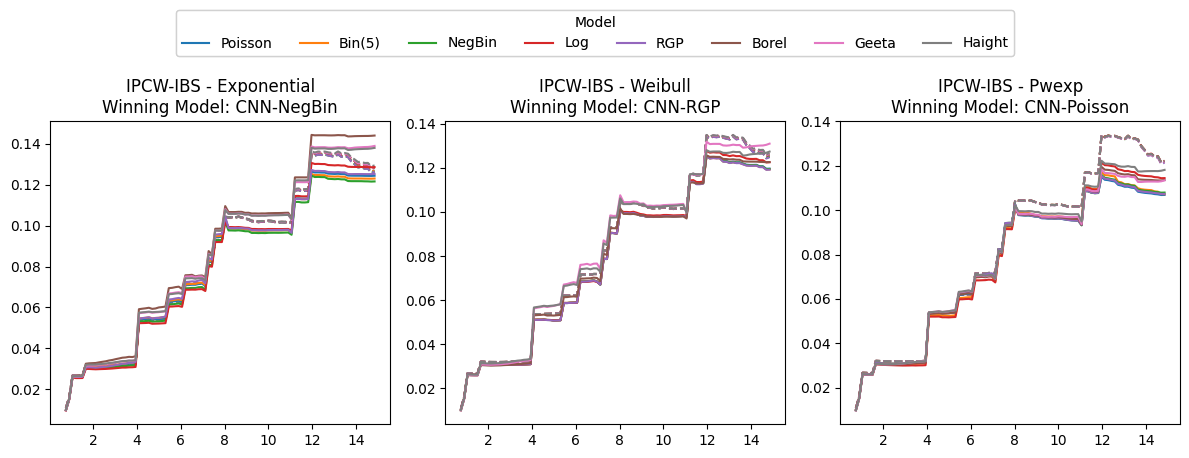

In [13]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
group_handles = []

fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (12,4))

for i in range(model_results.shape[0]):
    if(model_results.iloc[i,1] == "Simple"):
        linestyle = "dashed"
    else:
        linestyle = "solid"

    if(model_results.iloc[i,0] == "Exp"):
        # mask = grid_times_bs > 12
        # ax[0].plot(grid_times_bs[mask], bs_curves_times[i][mask], linestyle = linestyle, color = colors[i % 8])
        ax[0].plot(grid_times_bs, bs_curves_times[i], linestyle = linestyle, color = colors[i % 8])
    elif(model_results.iloc[i,0] == "Weibull"):
        # mask = grid_times_bs > 12
        # ax[0].plot(grid_times_bs[mask], bs_curves_times[i][mask], linestyle = linestyle, color = colors[i % 8])
        ax[1].plot(grid_times_bs, bs_curves_times[i], linestyle = linestyle, color = colors[i % 8])
    elif(model_results.iloc[i,0] == "Pwexp"):
        # mask = grid_times_bs > 12
        # ax[2].plot(grid_times_bs[mask], bs_curves_times[i][mask], linestyle = linestyle, color = colors[i % 8])
        ax[2].plot(grid_times_bs, bs_curves_times[i], linestyle = linestyle, color = colors[i % 8])

group_handles = [
    Line2D([0], [0], color = colors[0], linestyle = '-', label = "Poisson"),
    Line2D([0], [0], color = colors[1], linestyle = '-', label = "Bin(5)"),
    Line2D([0], [0], color = colors[2], linestyle = '-', label = "NegBin"),
    Line2D([0], [0], color = colors[3], linestyle = '-', label = "Log"),
    Line2D([0], [0], color = colors[4], linestyle = '-', label = "RGP"),
    Line2D([0], [0], color = colors[5], linestyle = '-', label = "Borel"),
    Line2D([0], [0], color = colors[6], linestyle = '-', label = "Geeta"),
    Line2D([0], [0], color = colors[7], linestyle = '-', label = "Haight"),
]

# Add the first legend (Groups) - Anchored to the top left
legend1 = fig.legend(
    handles = group_handles, 
    loc = 'upper center', 
    bbox_to_anchor = (0.5, 1.15), # Centered horizontally and pushed just above the figure
    title = "Model",
    ncol = 8
)

exp_results = model_results.loc[model_results["Base dist"] == "Exp", :].sort_values("IBS")
ax[0].set_title("IPCW-IBS - Exponential\nWinning Model: {}-{}".format( exp_results.iloc[0,1], exp_results.iloc[0,2] ))

weibull_results = model_results.loc[model_results["Base dist"] == "Weibull", :].sort_values("IBS")
ax[1].set_title("IPCW-IBS - Weibull\nWinning Model: {}-{}".format( weibull_results.iloc[0,1], weibull_results.iloc[0,2] ))

pwexp_results = model_results.loc[model_results["Base dist"] == "Pwexp", :].sort_values("IBS")
ax[2].set_title("IPCW-IBS - Pwexp\nWinning Model: {}-{}".format( pwexp_results.iloc[0,1], pwexp_results.iloc[0,2] ))

fig.add_artist(legend1)
fig.tight_layout()

# group_handles.append( Line2D([0], [0], color = colors[i % 8], linestyle = '-', label = model_names[i]) )

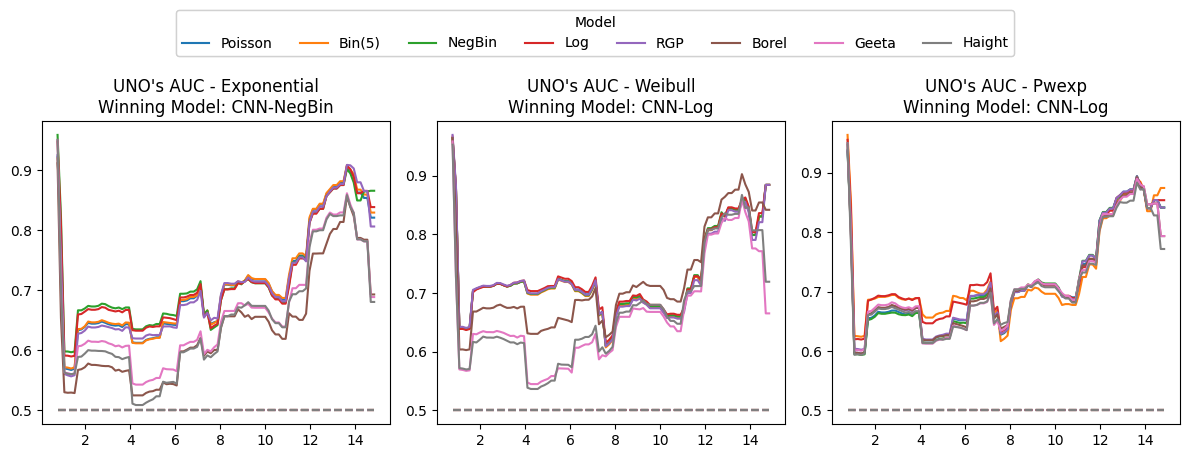

In [14]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
group_handles = []

fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (12,4))

for i in range(model_results.shape[0]):
    if(model_results.iloc[i,1] == "Simple"):
        linestyle = "dashed"
    else:
        linestyle = "solid"

    if(model_results.iloc[i,0] == "Exp"):
        # mask = grid_times_auc > 12
        # ax[0].plot(grid_times_auc[mask], auc_curves_times[i][mask], linestyle = linestyle, color = colors[i % 8])
        ax[0].plot(grid_times_auc, auc_curves_times[i], linestyle = linestyle, color = colors[i % 8])
    elif(model_results.iloc[i,0] == "Weibull"):
        # mask = grid_times_auc > 12
        # ax[0].plot(grid_times_auc[mask], auc_curves_times[i][mask], linestyle = linestyle, color = colors[i % 8])
        ax[1].plot(grid_times_auc, auc_curves_times[i], linestyle = linestyle, color = colors[i % 8])
    elif(model_results.iloc[i,0] == "Pwexp"):
        # mask = grid_times_auc > 12
        # ax[2].plot(grid_times_auc[mask], auc_curves_times[i][mask], linestyle = linestyle, color = colors[i % 8])
        ax[2].plot(grid_times_auc, auc_curves_times[i], linestyle = linestyle, color = colors[i % 8])

group_handles = [
    Line2D([0], [0], color = colors[0], linestyle = '-', label = "Poisson"),
    Line2D([0], [0], color = colors[1], linestyle = '-', label = "Bin(5)"),
    Line2D([0], [0], color = colors[2], linestyle = '-', label = "NegBin"),
    Line2D([0], [0], color = colors[3], linestyle = '-', label = "Log"),
    Line2D([0], [0], color = colors[4], linestyle = '-', label = "RGP"),
    Line2D([0], [0], color = colors[5], linestyle = '-', label = "Borel"),
    Line2D([0], [0], color = colors[6], linestyle = '-', label = "Geeta"),
    Line2D([0], [0], color = colors[7], linestyle = '-', label = "Haight"),
]

# Add the first legend (Groups) - Anchored to the top left
legend1 = fig.legend(
    handles = group_handles, 
    loc = 'upper center', 
    bbox_to_anchor = (0.5, 1.15), # Centered horizontally and pushed just above the figure
    title = "Model",
    ncol = 8
)

exp_results = model_results.loc[model_results["Base dist"] == "Exp", :].sort_values("Mean AUC", ascending = False)
ax[0].set_title("UNO's AUC - Exponential\nWinning Model: {}-{}".format( exp_results.iloc[0,1], exp_results.iloc[0,2] ))

weibull_results = model_results.loc[model_results["Base dist"] == "Weibull", :].sort_values("Mean AUC", ascending = False)
ax[1].set_title("UNO's AUC - Weibull\nWinning Model: {}-{}".format( weibull_results.iloc[0,1], weibull_results.iloc[0,2] ))

pwexp_results = model_results.loc[model_results["Base dist"] == "Pwexp", :].sort_values("Mean AUC", ascending = False)
ax[2].set_title("UNO's AUC - Pwexp\nWinning Model: {}-{}".format( pwexp_results.iloc[0,1], pwexp_results.iloc[0,2] ))

fig.add_artist(legend1)
fig.tight_layout()

# group_handles.append( Line2D([0], [0], color = colors[i % 8], linestyle = '-', label = model_names[i]) )

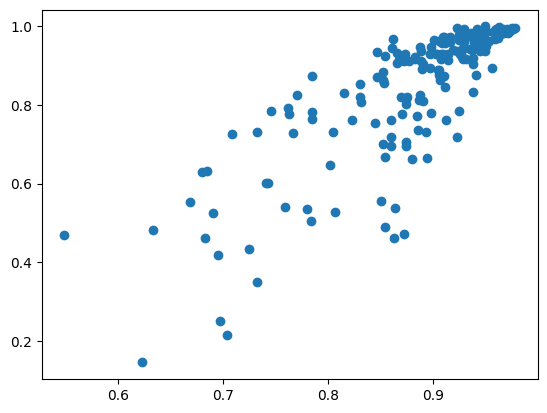

In [15]:
# Comparison between the cure probability predictions for the Negative Binomial Weibull and Pwexp models
negbin_spec = mpscr.MPSNegBinomial()
q_negbin_weibull = negbin_medium_model_weibull.predict("q")
raw_p_negbin_weibull = negbin_medium_model_weibull.predict(x_test)["raw_p"].numpy().flatten()
p_negbin_weibull = tf.math.sigmoid(raw_p_negbin_weibull).numpy()

q_rgp_pwexp = negbin_medium_model_pwexp.predict("q")
raw_p_negbin_pwexp = negbin_medium_model_pwexp.predict(x_test)["raw_p"].numpy().flatten()
p_negbin_pwexp = tf.math.sigmoid(raw_p_negbin_pwexp).numpy()

plt.plot(p_negbin_weibull, p_negbin_pwexp, "o")
plt.show()

## Final Model Analysis

Judging by the three top 10 results matrices, we select the winning model as the one that considers the piecewise-exponential distribution with 5 knots as the base while also considering the standard Poisson distribution for the number of latent causes. Surprisingly, that is the exact same model originally proposed by Xie & Yu (2021), event though here we consider a bigger dataset while also adopting a completely different approach to the model, where we optimize the observed log-likelihood function directly, without resorting to the EM algorithm.

That result suggests that our generalization works quite well and that the original structure proposed by Xie & Yu is mantained. With these results, we are much more confident of the predicting results for each patient. Here we can also rely on the GNDR models framework to obtain confidence intervals for the survival predictions, which provided a much more robust and stable calculation than obtaining predictive intervals using the Bootstrap method.

In fact, below, we fix the Piecewise-exponential Poisson promotion time cure model as the selected model and all following conclusions are obtained considering that specific approach.

In [16]:
final_model = poisson_medium_model_pwexp
final_results = poisson_medium_results_pwexp

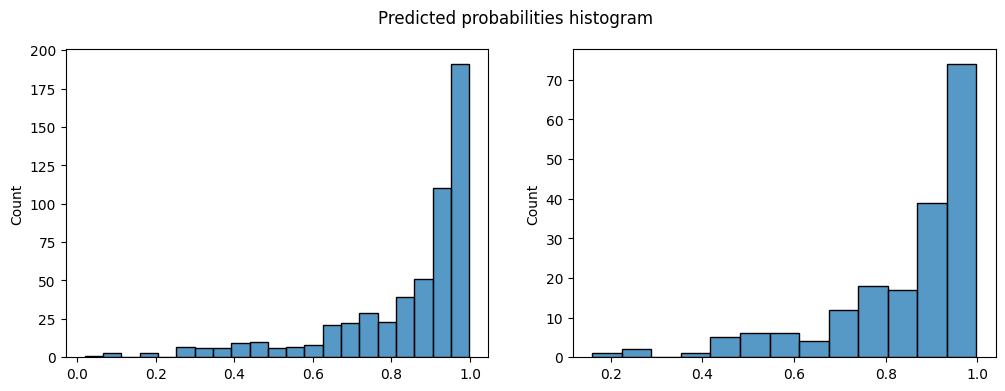

In [265]:
fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))

fig.suptitle("Predicted probabilities histogram".format(a, b))

sns.histplot(final_results["p_train"], ax = ax[0])
sns.histplot(final_results["p_test"], ax = ax[1])

plt.show()

Above, we can see the distribution for the predicted cure probabilities of all patients in the dataset. In order to make the simulation data as close as possible to this specific dataset, we can sample the cure probabilities associated to each patient from a Beta distribution obtained from the train cure probability values.

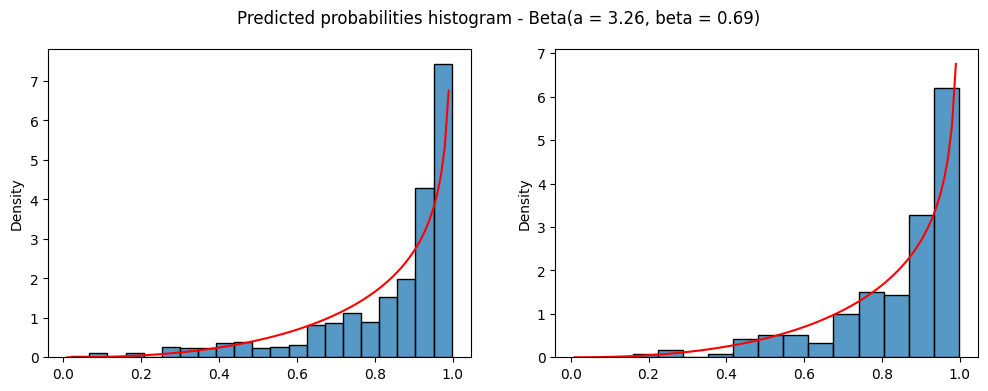

In [266]:
a, b, _, _ = beta.fit(final_results["p_train"], floc = 0.0, fscale = 1.0)

fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,4))
fig.suptitle("Predicted probabilities histogram - Beta(a = {:.2f}, beta = {:.2f})".format(a, b))

u = np.linspace(0.01, 1, 100)
sns.histplot(final_results["p_train"], ax = ax[0], stat = "density")
ax[0].plot(u, beta.pdf(u, a = a, b = b), color = "red")

sns.histplot(final_results["p_test"], ax = ax[1], stat = "density")
ax[1].plot(u, beta.pdf(u, a = a, b = b), color = "red")

plt.show()

The first analysis we are interested is in determining profile of the brain images for each strata of predicted probabilities. For the few patients whose predicted probability was low, we plot both their predicted survival curves and their MRI brain scans.

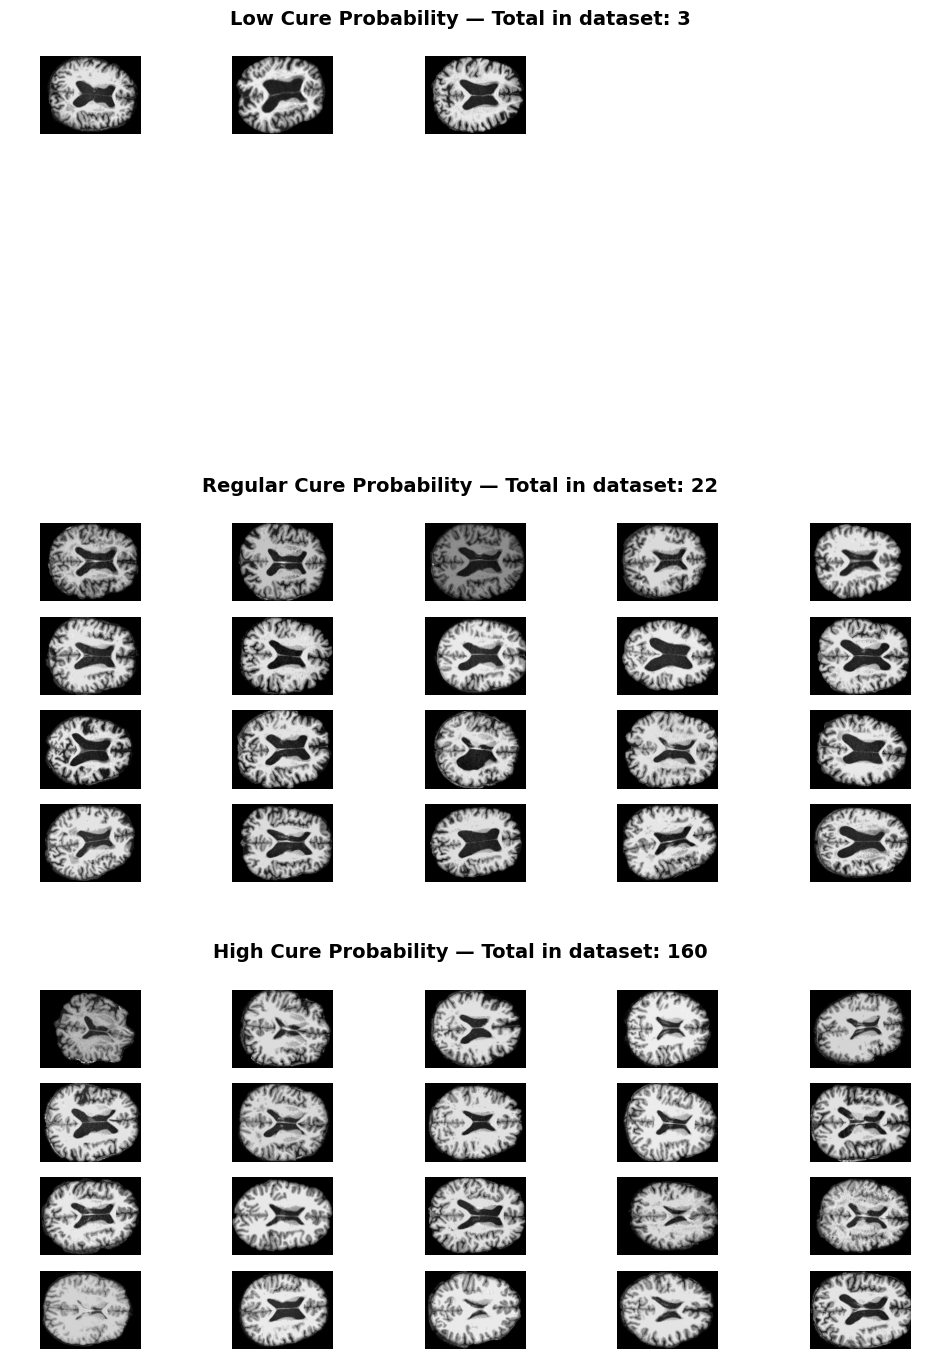

In [18]:
p_test = final_results["p_test"]

low_prob = p_test <= 1/3
regular_prob = (p_test > 1/3) & (p_test <= 2/3)
high_prob = p_test > 2/3

x_low_prob = x_test[low_prob]
x_regular_prob = x_test[regular_prob]
x_high_prob = x_test[high_prob]

dataset = {
    'Low Cure Probability': x_low_prob,
    'Regular Cure Probability': x_regular_prob,
    'High Cure Probability': x_high_prob
}

fig = plt.figure(figsize=(12, 14))

# Create 3 subfigures stacked vertically (one for each group)
subfigs = fig.subfigures(nrows=3, ncols=1, hspace=0.0)

for subfig, (group_name, image_tensor) in zip(subfigs, dataset.items()):
    # Get the total number of images (the first dimension 'n')
    n_total = image_tensor.shape[0]
    
    subfig.suptitle(f"{group_name} — Total in dataset: {n_total}", 
                    fontsize=14, fontweight='bold')
    
    # Sample random INDICES instead of the tensor itself
    n_samples = min(20, n_total)
    sampled_indices = random.sample(range(n_total), n_samples)
    
    # Slice the tensor using the sampled indices
    sampled_images = image_tensor[sampled_indices]
    
    axs = subfig.subplots(nrows=4, ncols=5)
    
    for i, ax in enumerate(axs.flat):
        if i < n_samples:
            # Remove that trailing '1' dimension before plotting
            # sampled_images[i] is shape (width, height, 1)
            # .squeeze() makes it (width, height)
            img_to_plot = sampled_images[i].squeeze() 
            
            # If your tensor is PyTorch/TensorFlow, you might need to convert 
            # to numpy first: img_to_plot = img_to_plot.numpy()
            
            ax.imshow(img_to_plot, cmap='gray')
        
        ax.axis('off')

# Display the final plot
plt.show()

In [19]:
def plot_test_stratas_avg(df_test, model_results, strata_indices, strata_names, ax = None, title = ""):
    if(ax is None):
        fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (6,4))

    ts_grid = model_results["ts_grid"]
    S_test_ts = model_results["S_ts_test"]
    y_test = model_results["y_test"]
    delta_test = model_results["delta_test"]
    
    for i in range(len(strata_indices)):
        utils.average_kaplan_meier(ts_grid,
                                   S_test_ts[strata_indices[i],:],
                                   y_test[strata_indices[i]], delta_test[strata_indices[i]],
                                   show_individual = False,
                                   color = colors[i], plot_km = False, ax = ax, km_color = colors[i])
    ax.set_title(title)
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Survival")

In [20]:
def plot_test_stratas_quantiles(df_test, model_results, strata_indices, strata_names, q, ax = None, title = ""):
    if(ax is None):
        fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (6,4))

    ts_grid = model_results["ts_grid"]
    S_test_ts = model_results["S_ts_test"]
    y_test = model_results["y_test"]
    delta_test = model_results["delta_test"]
    
    for i in range(len(strata_indices)):
        utils.quantile_kaplan_meier(ts_grid,
                                    S_test_ts[strata_indices[i],:],
                                    y_test[strata_indices[i]], delta_test[strata_indices[i]],
                                    q,
                                    show_individual = False,
                                    color = colors[i], plot_km = False, ax = ax, km_color = colors[i])
    ax.set_title(title)
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Survival")

In [21]:
# MMSE evaluation
mmse_strata_names = [
    r"$=30$",
    r"$=27$",
    r"$<27$"
]
mmse_strata_indices = [
    np.where( df_test.loc[:,"mmse"] == 30 )[0],
    np.where( df_test.loc[:,"mmse"] == 27 )[0],
    np.where( (df_test.loc[:,"mmse"] < 27) )[0]
]

# Age evaluation
age_strata_names = [
    r"$<60$",
    r"$>60\leq70$",
    r"$>70\leq80$",
    r"$>80$"
]
age_strata_indices = [
    np.where(df_test.loc[:,"age_at_entry"] < 60)[0],
    np.where( (df_test.loc[:,"age_at_entry"] > 60) & (df_test.loc[:,"age_at_entry"] <= 70) )[0],
    np.where( (df_test.loc[:,"age_at_entry"] > 70) & (df_test.loc[:,"age_at_entry"] <= 80) )[0],
    np.where(df_test.loc[:,"age_at_entry"] >= 80)[0],
]

# Intracranial Volume evaluation
icv_strata_names = [
    r"$\geq 90\%$ quant",
    r"$\geq 20 < 90\%$ quant",
    r"$< 20\%$ quant"
]
icv_strata_indices = [
    np.where( df_test.loc[:,"icv"] >= np.quantile(df_test.loc[:,"icv"], 0.9) )[0],
    np.where( (df_test.loc[:,"icv"] >= np.quantile(df_test.loc[:,"icv"], 0.2)) & (df_test.loc[:,"icv"] < np.quantile(df_test.loc[:,"icv"], 0.9)) )[0],
    np.where( (df_test.loc[:,"icv"] < np.quantile(df_test.loc[:,"icv"], 0.2)) )[0]
]

# Intracranial Volume evaluation
scg_strata_names = [
    r"$\geq 90\%$ quant",
    r"$\geq 10 < 90\%$ quant",
    r"$< 10\%$ quant"
]
scg_strata_indices = [
    np.where( df_test.loc[:,"sub_cort_gray_vol"] >= np.quantile(df_test.loc[:,"sub_cort_gray_vol"], 0.9) )[0],
    np.where( (df_test.loc[:,"sub_cort_gray_vol"] >= np.quantile(df_test.loc[:,"sub_cort_gray_vol"], 0.1)) & (df_test.loc[:,"sub_cort_gray_vol"] < np.quantile(df_test.loc[:,"sub_cort_gray_vol"], 0.9)) )[0],
    np.where( (df_test.loc[:,"sub_cort_gray_vol"] < np.quantile(df_test.loc[:,"sub_cort_gray_vol"], 0.1)) )[0]
]

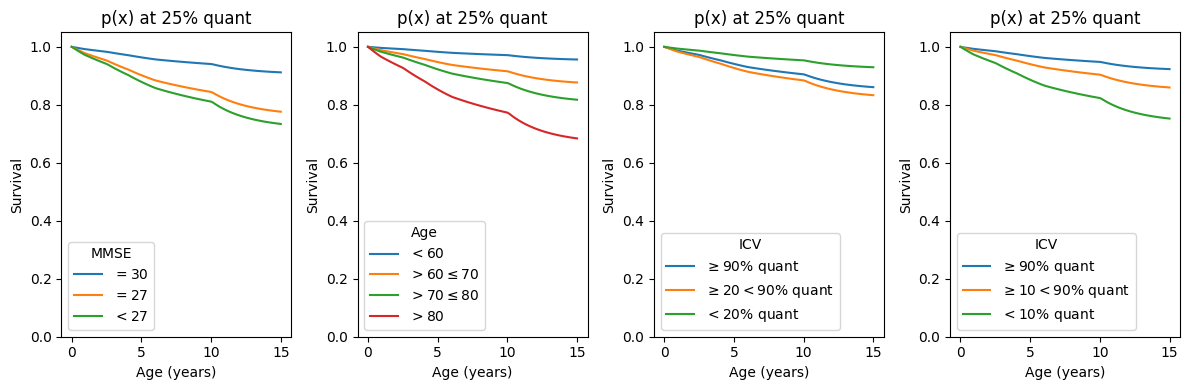

In [22]:
fig, ax = plt.subplots(nrows = 1, ncols = 4, figsize = (12,4))

plot_test_stratas_avg(df_test, final_results, mmse_strata_indices, mmse_strata_names, title = "p(x) at 25% quant", ax = ax[0])
plot_test_stratas_avg(df_test, final_results, age_strata_indices, age_strata_names, title = "p(x) at 25% quant", ax = ax[1])
plot_test_stratas_avg(df_test, final_results, icv_strata_indices, icv_strata_names, title = "p(x) at 25% quant", ax = ax[2])
plot_test_stratas_avg(df_test, final_results, scg_strata_indices, scg_strata_names, title = "p(x) at 25% quant", ax = ax[3])

mmse_group_handles = [
    Line2D([0], [0], color = colors[i], linestyle = '-', label = mmse_strata_names[i]) for i in range(len(mmse_strata_indices))
]
legend_ages = ax[0].legend(
    handles = mmse_group_handles, 
    loc = "lower left", 
    title = "MMSE"
)

age_group_handles = [
    Line2D([0], [0], color = colors[i], linestyle = '-', label = age_strata_names[i]) for i in range(len(age_strata_indices))
]
legend_ages = ax[1].legend(
    handles = age_group_handles, 
    loc = "lower left", 
    title = "Age"
)

icv_group_handles = [
    Line2D([0], [0], color = colors[i], linestyle = '-', label = icv_strata_names[i]) for i in range(len(icv_strata_indices))
]
legend_ages = ax[2].legend(
    handles = icv_group_handles, 
    loc = "lower left", 
    title = "ICV"
)

scg_group_handles = [
    Line2D([0], [0], color = colors[i], linestyle = '-', label = scg_strata_names[i]) for i in range(len(scg_strata_indices))
]
legend_ages = ax[3].legend(
    handles = scg_group_handles, 
    loc = "lower left", 
    title = "ICV"
)

fig.tight_layout()

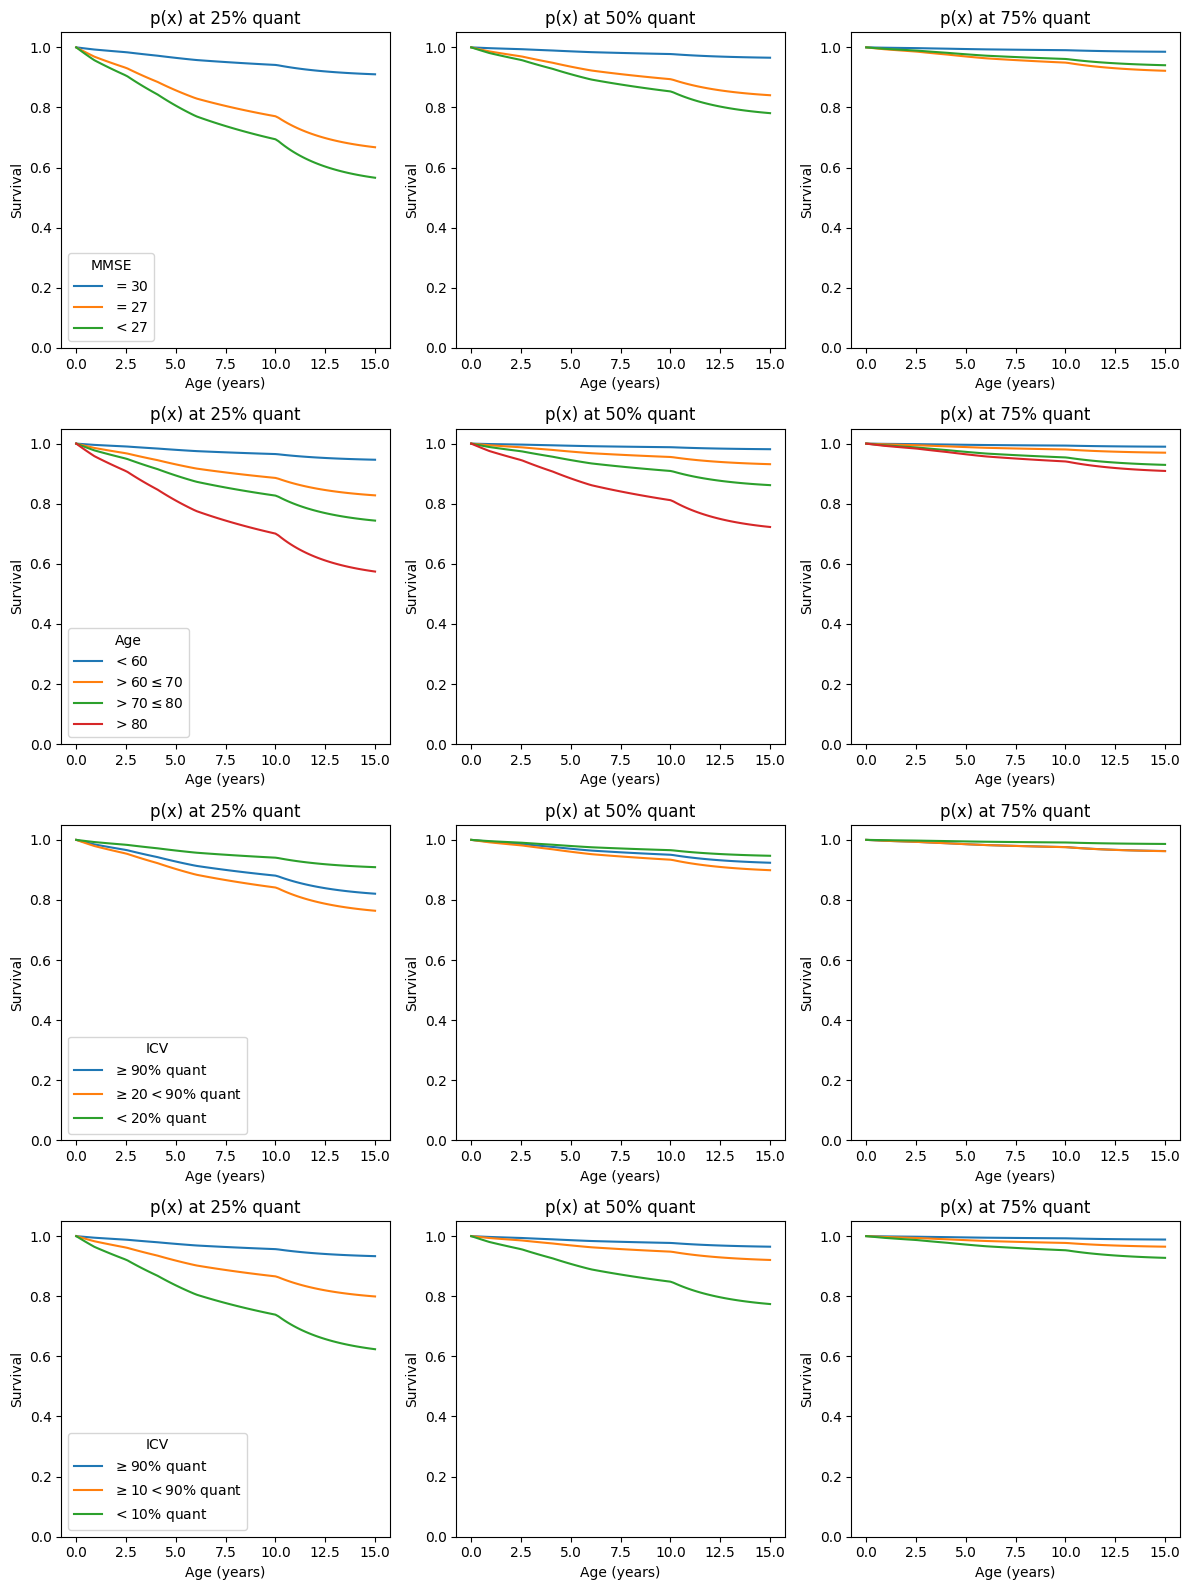

In [23]:
fig, ax = plt.subplots(nrows = 4, ncols = 3, figsize = (12,16))

plot_test_stratas_quantiles(df_test, final_results, mmse_strata_indices, mmse_strata_names, 0.25, title = "p(x) at 25% quant", ax = ax[0,0])
plot_test_stratas_quantiles(df_test, final_results, mmse_strata_indices, mmse_strata_names, 0.5, title = "p(x) at 50% quant", ax = ax[0,1])
plot_test_stratas_quantiles(df_test, final_results, mmse_strata_indices, mmse_strata_names, 0.75, title = "p(x) at 75% quant", ax = ax[0,2])

plot_test_stratas_quantiles(df_test, final_results, age_strata_indices, age_strata_names, 0.25, title = "p(x) at 25% quant", ax = ax[1,0])
plot_test_stratas_quantiles(df_test, final_results, age_strata_indices, age_strata_names, 0.5, title = "p(x) at 50% quant", ax = ax[1,1])
plot_test_stratas_quantiles(df_test, final_results, age_strata_indices, age_strata_names, 0.75, title = "p(x) at 75% quant", ax = ax[1,2])

plot_test_stratas_quantiles(df_test, final_results, icv_strata_indices, icv_strata_names, 0.25, title = "p(x) at 25% quant", ax = ax[2,0])
plot_test_stratas_quantiles(df_test, final_results, icv_strata_indices, icv_strata_names, 0.5, title = "p(x) at 50% quant", ax = ax[2,1])
plot_test_stratas_quantiles(df_test, final_results, icv_strata_indices, icv_strata_names, 0.75, title = "p(x) at 75% quant", ax = ax[2,2])

plot_test_stratas_quantiles(df_test, final_results, scg_strata_indices, scg_strata_names, 0.25, title = "p(x) at 25% quant", ax = ax[3,0])
plot_test_stratas_quantiles(df_test, final_results, scg_strata_indices, scg_strata_names, 0.5, title = "p(x) at 50% quant", ax = ax[3,1])
plot_test_stratas_quantiles(df_test, final_results, scg_strata_indices, scg_strata_names, 0.75, title = "p(x) at 75% quant", ax = ax[3,2])

mmse_group_handles = [
    Line2D([0], [0], color = colors[i], linestyle = '-', label = mmse_strata_names[i]) for i in range(len(mmse_strata_indices))
]
legend_ages = ax[0,0].legend(
    handles = mmse_group_handles, 
    loc = "lower left", 
    title = "MMSE"
)

age_group_handles = [
    Line2D([0], [0], color = colors[i], linestyle = '-', label = age_strata_names[i]) for i in range(len(age_strata_indices))
]
legend_ages = ax[1,0].legend(
    handles = age_group_handles, 
    loc = "lower left", 
    title = "Age"
)

icv_group_handles = [
    Line2D([0], [0], color = colors[i], linestyle = '-', label = icv_strata_names[i]) for i in range(len(icv_strata_indices))
]
legend_ages = ax[2,0].legend(
    handles = icv_group_handles, 
    loc = "lower left", 
    title = "ICV"
)

scg_group_handles = [
    Line2D([0], [0], color = colors[i], linestyle = '-', label = scg_strata_names[i]) for i in range(len(scg_strata_indices))
]
legend_ages = ax[3,0].legend(
    handles = scg_group_handles, 
    loc = "lower left", 
    title = "ICV"
)

fig.tight_layout()

In [24]:
final_results["S_ts_test"].shape

(185, 100)

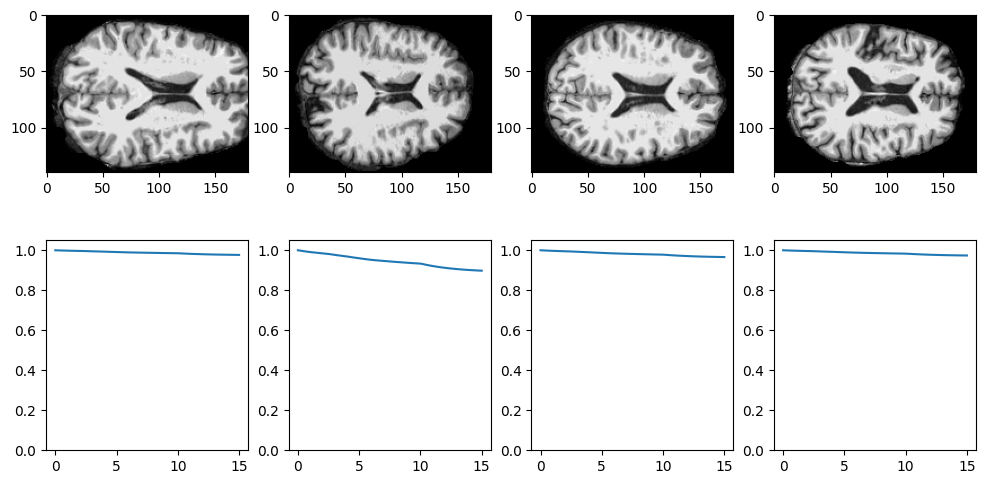

In [25]:
np.random.seed(10)

n_patients = 4
sample_patients_test = np.random.choice(np.arange(df_test.shape[0]), size = n_patients)

fig, ax = plt.subplots(nrows = 2, ncols = n_patients, figsize = (12,6))

for i in range(n_patients):  
    ax[0,i].imshow(x_test[sample_patients_test[i]], cmap = "gray")
    ax[1,i].plot(final_results["ts_grid"], final_results["S_ts_test"][sample_patients_test[i], :])
    ax[1,i].set_ylim(0, 1.05)

In [26]:
# def get_survival_cure(self, y_train, delta_train, X_train, y_test, delta_test, X_test, ngrid = 100):
self = final_model
fixed_q = 1.0
ngrid = 100
base_spec = mpscr.BasePiecewiseExp(y = y_train, delta = delta_train, n_cuts = 5)

y_train_safe = tf.cast( y_train.copy(), tf.float32 )
y_test_safe = tf.cast( y_test.copy(), tf.float32 )
if(len(y_train_safe.shape) == 1):
    y_train_safe = tf.reshape(y_train_safe, shape=(len(y_train_safe), 1))
if(len(y_test_safe.shape) == 1):
    y_test_safe = tf.reshape(y_test_safe, shape=(len(y_test_safe), 1))

pred_train = self.predict(x_train)
pred_test = self.predict(x_test)

alpha = self.predict("alpha")[None,:]
if(self.hasq):
    q = self.predict("q")
else:
    q = fixed_q

ts_grid = np.linspace(0.0001 , np.max(np.concatenate([y_train, y_test])), ngrid)[:,None]

eps = tf.constant(1.0e-5, dtype = tf.float32)
raw_p_train = pred_train["raw_p"].numpy().flatten()
raw_p_test = pred_test["raw_p"].numpy().flatten()

p_train = tf.math.sigmoid(raw_p_train) * (self.p_max(q) - self.p_min(q)) + self.p_min(q)
p_test = tf.math.sigmoid(raw_p_test) * (self.p_max(q) - self.p_min(q)) + self.p_min(q)

p_train = tf.clip_by_value(p_train, eps, 1.0-eps)
p_test = tf.clip_by_value(p_test, eps, 1.0-eps)

theta_train = self.C_inv( self.a0(q) / p_train, q )
theta_test = self.C_inv( self.a0(q) / p_test, q )

S0_ts = tf.reshape( tf.cast( base_spec.survival(ts_grid, alpha), tf.float32 ), [-1,1] )
S0_train = tf.squeeze( tf.cast( base_spec.survival(y_train_safe, alpha), tf.float32 ) )
S0_test = tf.squeeze( tf.cast( base_spec.survival(y_test_safe, alpha), tf.float32 ) )

u_ts_train = S0_ts * self.phi(theta_train, q)
u_ts_test = S0_ts * self.phi(theta_test, q)
u_train = S0_train * self.phi(theta_train, q)
u_test = S0_test * self.phi(theta_test, q)

A_u_ts_train = self.A( u_ts_train, q )
A_u_ts_test = self.A( u_ts_test, q )
A_u_train = self.A( u_train, q )
A_u_test = self.A( u_test, q )

C_theta_train = self.C( theta_train, q )
C_theta_test = self.C( theta_test, q )

S_ts_train = (A_u_ts_train / C_theta_train).numpy()
S_ts_test = (A_u_ts_test / C_theta_test).numpy()
S_train = (A_u_train / C_theta_train).numpy()
S_test = (A_u_test / C_theta_test).numpy()

H_train = -np.log( S_train )
H_test = -np.log( S_test )

if(hasattr(y_train, "to_numpy")):
    y_train = y_train.to_numpy()
if(hasattr(delta_train, "to_numpy")):
    delta_train = delta_train.to_numpy()
if(hasattr(y_test, "to_numpy")):
    y_test = y_test.to_numpy()
if(hasattr(delta_test, "to_numpy")):
    delta_test = delta_test.to_numpy()

results_dict = {
    "ts_grid": ts_grid,
    "S_ts_train": S_ts_train.T,
    "S_ts_test": S_ts_test.T,
    "y_train":y_train,
    "y_test": y_test,
    "delta_train": delta_train,
    "delta_test": delta_test,
    "S_train": S_train,
    "S_test": S_test,
    "H_train": H_train,
    "H_test": H_test,
    "theta_train": theta_train,
    "theta_test": theta_test,
    "p_train": p_train,
    "p_test": p_test,
    "alpha": alpha
}
# Runs through all elements in the results dictionary and convert them to numpy, if possible
for key in results_dict:
    if(hasattr(results_dict[key], "to_numpy")):
        results_dict[key] = results_dict[key].to_numpy()
    if(hasattr(results_dict[key], "numpy")):
        results_dict[key] = results_dict[key].numpy()
        
# The observed survival values for patients correspond to a 1d vector
results_dict["S_train"] = results_dict["S_train"].flatten()
results_dict["S_test"] = results_dict["S_test"].flatten()
results_dict["H_train"] = results_dict["H_train"].flatten()
results_dict["H_test"] = results_dict["H_test"].flatten()

# Interval prediction

### Must implement interval prediction for all patients beforehand

In [148]:
def get_log_hazard_bounds(model, x, y, delta, patient_indices, ngrid = 50, confidence = 0.95):
    """
        This function extracts the log cumulative hazard from the model
    """
    def log_cumulative_hazard(model, nn_output, data):
        X, ts, delta = data
        
        alpha = model.get_variable("alpha")[None,:]
        if(model.hasq):
            q = model.get_variable("q")
        else:
            q = 0.0
        raw_p = model.get_variable("raw_p", nn_output)
        p = tf.math.sigmoid(raw_p) * (model.p_max(q) - model.p_min(q)) + model.p_min(q)
    
        theta = model.C_inv( model.a0(q) / p, q )
    
        S0 = tf.reshape( model.base_spec.survival(ts, alpha), [1,-1] )
        u = S0 * model.phi(theta, q)
        A_u = model.A( u, q )
        
        log_H_t = tf.math.log( tf.math.log(model.C(theta, q)) - tf.math.log(A_u) )
        return log_H_t

    # Create a grid of values for prediction
    ts = tf.constant( np.linspace(0.01, np.max(y), ngrid)[None,:], dtype = tf.float32 )
    ts_flat = ts.numpy().flatten()
    
    if( model.hasq ):
        q = loglogistic_model.predict("q")
    else:
        q = model.fixed_q
    
    new_x = x[patient_indices, :, :, :]
    new_alpha = model.predict( new_x )["raw_p"]
    new_data = [ ts, tf.gather(delta_test, patient_indices) ]
    nn_output = model( new_x )

    # For each patient, get a covariance matrix for the log cumulative hazard function at each grid point t
    # This returns a tensor of size (n_patients, ngrid, ngrid)
    log_cumulative_hazard_covariances = model.variable_function_covariance(
        fun = log_cumulative_hazard,
        data = new_data,
        x = x[patient_indices,:,:,:]
    )
    # Take the diagonal of the hazard matrices, resulting in the variance for each time in the grid
    log_cumulative_hazard_variances = np.diagonal(log_cumulative_hazard_covariances, axis1 = 1, axis2 = 2)

    # Obtain confidence bounds for each log cumulative hazard curve
    z_norm = norm.ppf(1-(1-confidence)/2)
    log_cumulative_hazard_values = (log_cumulative_hazard(final_model, nn_output, [new_x] + new_data)).numpy()
    log_cumulative_hazard_lower = log_cumulative_hazard_values - z_norm * np.sqrt(log_cumulative_hazard_variances)
    log_cumulative_hazard_upper = log_cumulative_hazard_values + z_norm * np.sqrt(log_cumulative_hazard_variances)
    
    return ts_flat, log_cumulative_hazard_values, log_cumulative_hazard_lower, log_cumulative_hazard_upper

In [200]:
def plot_patients_survival(model, x, y, delta, patient_indices, ngrid = 50, confidence = 0.95, ax1 = None, ax2 = None):
    if(ax1 is None or ax2 is None):
        fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (8,4))
        ax1 = ax[0]
        ax2 = ax[1]
    
    ts_flat, log_cumulative_hazard_values, log_cumulative_hazard_lower, log_cumulative_hazard_upper =\
    get_log_hazard_bounds(model, x, y, delta, patient_indices, ngrid = ngrid, confidence = confidence)

    survival_values = np.exp(-np.exp( log_cumulative_hazard_values ))
    survival_lower = np.exp(-np.exp( log_cumulative_hazard_lower ))
    survival_upper = np.exp(-np.exp( log_cumulative_hazard_upper ))

    # log_cumulative_hazard_upper.shape
    for i in range(len(patient_indices)):
        ax1.plot(ts_flat, log_cumulative_hazard_values[i, :], color = colors[i])
        ax1.plot(ts_flat, log_cumulative_hazard_lower[i, :], color = colors[i], linestyle = "dashed")
        ax1.plot(ts_flat, log_cumulative_hazard_upper[i, :], color = colors[i], linestyle = "dashed")
    
        ax2.plot(ts_flat, survival_values[i, :], color = colors[i])
        ax2.plot(ts_flat, survival_lower[i, :], color = colors[i], linestyle = "dashed")
        ax2.plot(ts_flat, survival_upper[i, :], color = colors[i], linestyle = "dashed")
    
    ax1.set_title("Confidence Bounds\nLog Cumulative Hazard")
    ax2.set_title("Confidence Bounds\nSurvival")
    
    group_handles = [
        Line2D([0], [0], color = colors[i], linestyle = '-', label = "Patient {}".format(patient_indices[i])) for i in range(len(patient_indices))
    ]
    legend1 = fig.legend(
        handles = group_handles,
        loc = 'upper center',
        bbox_to_anchor = (0.5, 1.15), # Centered horizontally and pushed just above the figure
        title = "Patient",
        ncol = 8
    )

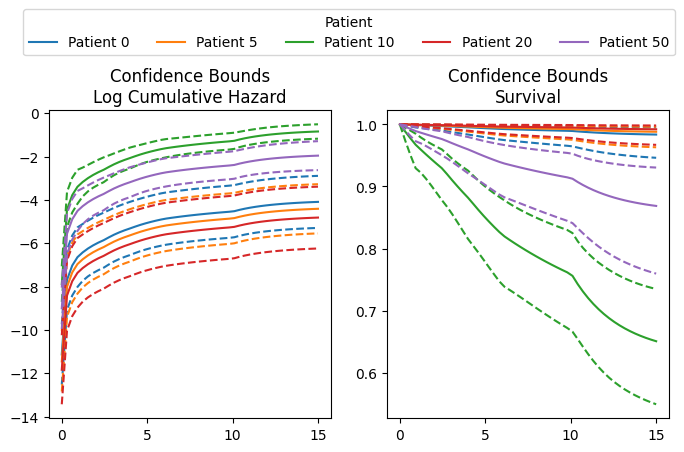

In [275]:
patient_indices = [0, 5, 10, 20, 50]
plot_patients_survival(final_model, x_test, y_test, delta_test, patient_indices, ngrid = 50, confidence = 0.95, ax1 = None, ax2 = None)

In [207]:
def plot_patients_survival2(model, x, y, delta, patient_indices, ngrid = 50, confidence = 0.95):
    fig, ax = plt.subplots(nrows = 2, ncols = len(patient_indices), figsize = (4*len(patient_indices),6))

    new_x = x[patient_indices, :, :, :]
    new_alpha = model.predict( new_x )["raw_p"]
    new_data = [ ts, tf.gather(delta_test, patient_indices) ]
    nn_output = model( new_x )
    
    raw_p = model.predict(new_x)["raw_p"]
    p = tf.math.sigmoid(raw_p) * (model.p_max(q) - model.p_min(q)) + model.p_min(q)
    theta = model.C_inv( model.a0(q) / p, q ).numpy().flatten()
    ts_flat, log_cumulative_hazard_values, log_cumulative_hazard_lower, log_cumulative_hazard_upper =\
    get_log_hazard_bounds(model, x, y, delta, patient_indices, ngrid = ngrid, confidence = confidence)

    survival_values = np.exp(-np.exp( log_cumulative_hazard_values ))
    survival_lower = np.exp(-np.exp( log_cumulative_hazard_lower ))
    survival_upper = np.exp(-np.exp( log_cumulative_hazard_upper ))
    
    for i in range(len(patient_indices)):
        ax[0,i].imshow(x[patient_indices[i]], cmap = "gray")
        # color_i = colors[i]
        color_i = "black"
        ax[1,i].plot(ts_flat, survival_values[i, :], color = color_i)
        ax[1,i].plot(ts_flat, survival_lower[i, :], color = color_i, linestyle = "dashed")
        ax[1,i].plot(ts_flat, survival_upper[i, :], color = color_i, linestyle = "dashed")
        ax[1,i].set_ylim(0, 1.05)
        ax[0,i].set_title(r"Patient {} - $\widehat \theta$ = {:.2f}".format(patient_indices[i], np.round(theta[i], 2) ))

In [220]:
# Select a diverse set of patients with respect to their theta values

alpha = final_model.get_variable("alpha")[None,:]
if(final_model.hasq):
    q = final_model.get_variable("q")
else:
    q = 0.0
raw_p_test = final_model.predict(x_test)["raw_p"]
p_test = tf.math.sigmoid(raw_p_test) * (final_model.p_max(q) - final_model.p_min(q)) + final_model.p_min(q)
theta_test = final_model.C_inv( final_model.a0(q) / p_test, q ).numpy().flatten()
theta_sort_indices = np.argsort(theta_test)
print("Test patients index for ascending theta:\n{}".format(theta_sort_indices))

Test patients index for ascending theta:
[136  55 165  68 108  65 144  94 110  20 162 140  28 174  40 128  80  70
 131 178   5  47 173 157 149  42   0 180 172 106  85  31 171 143   9 116
  16  45  64   4 156  24  90 100 154  67 121 123  15   1 142  71  60 150
  91  99 105 132 152 159  89 124  12 122 155  30  22 160  58 151  36 170
 129  62  54 109 120 182 139 133  95 161  43  14  87  17 119  19 102  96
 177 179 167 183  76 101  56  73 175 184 138  66  41 146   3  93   6   8
  39 125  53 117 118  74  83  50 113  81  44  23  97  86 104  72  78 103
 158  35  25 164  32  37 145  79   7  18  21  13  52  92  98  63 130  34
 115 111 168  75   2 153  77  38 181 137  57 163 112  48  69  82 147  10
  11 166 127  46 114  27 134  51  84 148  61  26  88  49 169 107  59  33
 135 176 126 141  29]


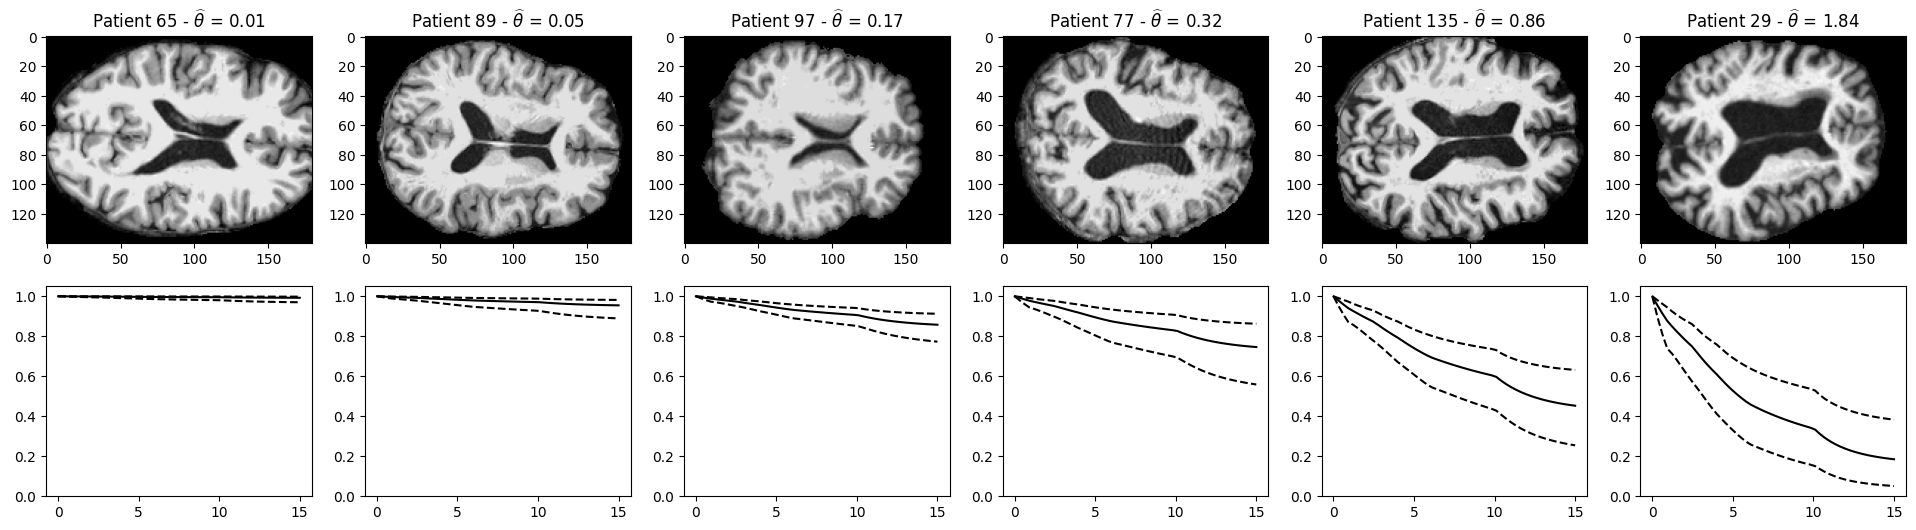

In [274]:
patient_indices = [65, 89, 97, 77, 135, 29]
plot_patients_survival2(final_model, x_test, y_test, delta_test, patient_indices, ngrid = 50, confidence = 0.95)